In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 


In [4]:
# attempts at 2D fourier 
# notation from here https://www.youtube.com/watch?v=YYGltoYEmKo&t=777s
# m (vertical),n(horiz) in space and u (vert),v(horiz) in freq


In [5]:
N = 64
r = 36

f = np.zeros((N,N))    
f1=f;f2=f;f3=f;f4=f;f5=f;
NN = np.arange(N)
IN = np.ones(N)

In [6]:
f1 = np.cos(4*2*np.pi/N*np.kron(IN.reshape(N,1),NN))  # u=0 v=6*2pi/64 
f2 = f1 + np.cos(8*2*np.pi/N*np.kron(IN.reshape(N,1),NN))  # u=0 v=50pi/256 
f3 = np.cos(8*2*np.pi/N*np.kron(NN.reshape(N,1),IN))  # u=100pi/256 v=0 
f4 = np.kron(np.cos(8*2*np.pi/N*NN.reshape(N,1)),np.cos(8*2*np.pi/N*NN))  # u=100pi/256 v=0 

In [7]:
f5 += np.kron(np.cos(16*np.pi*NN/N).reshape(N,1),np.cos(4*np.pi*NN/N))
f5 += np.kron(np.cos(4*np.pi*NN/N).reshape(N,1),np.cos(16*np.pi*NN/N))

In [8]:
import scipy.fftpack as sfft

F1 = np.fft.fft2(f1);    F1 = sfft.fftshift(F1) 
F2 = np.fft.fft2(f2);    F2 = sfft.fftshift(F2)
F3 = np.fft.fft2(f3);    F3 = sfft.fftshift(F3)
F4 = np.fft.fft2(f4);    F4 = sfft.fftshift(F4)
F5 = np.fft.fft2(f5);    F5 = sfft.fftshift(F5)


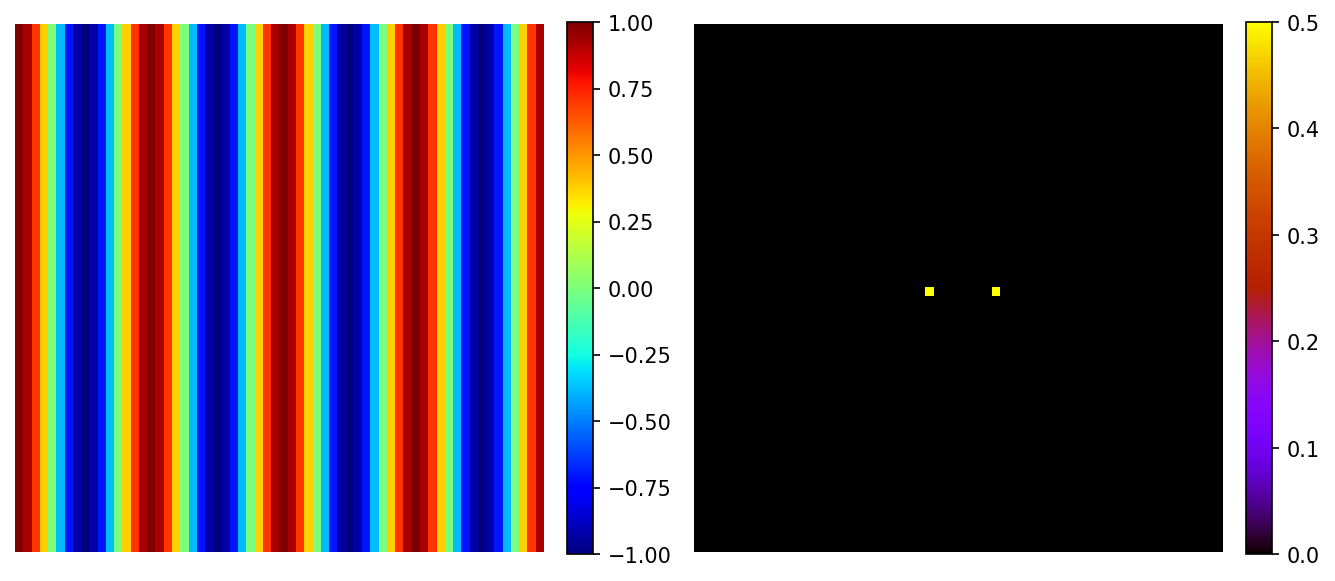

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(f1, cmap='jet')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(np.real(F1)/N**2, cmap='gnuplot')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_1.pdf', dpi=300)
plt.show()

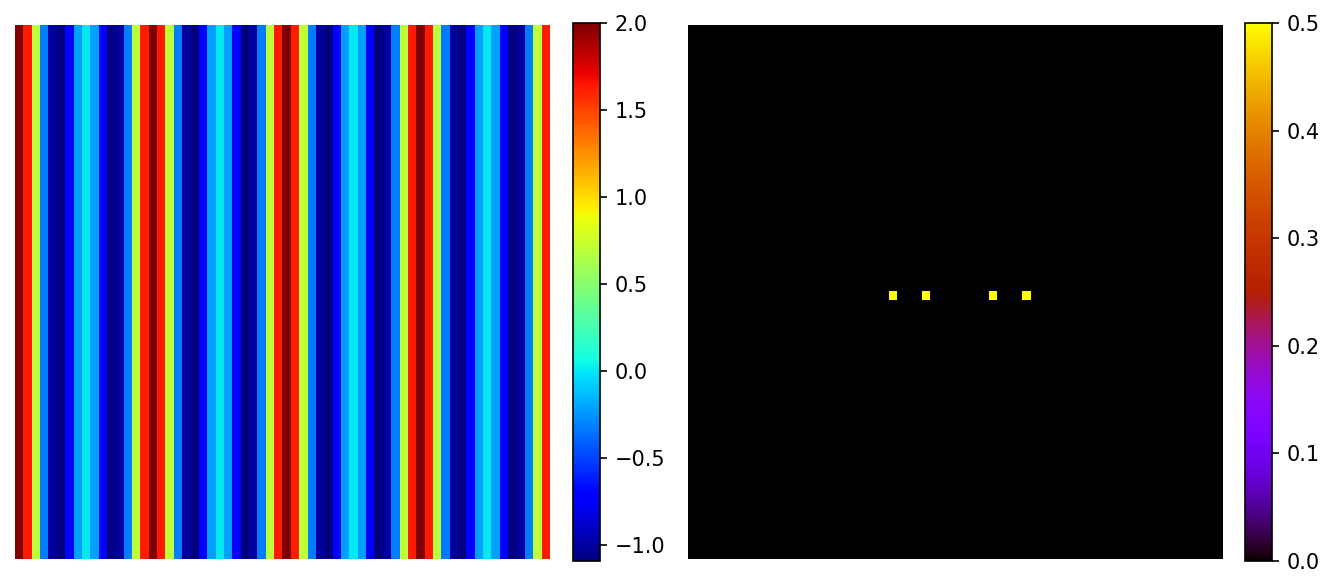

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(f2, cmap='jet')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(np.real(F2)/N**2, cmap='gnuplot')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_2.pdf', dpi=300)
plt.show()

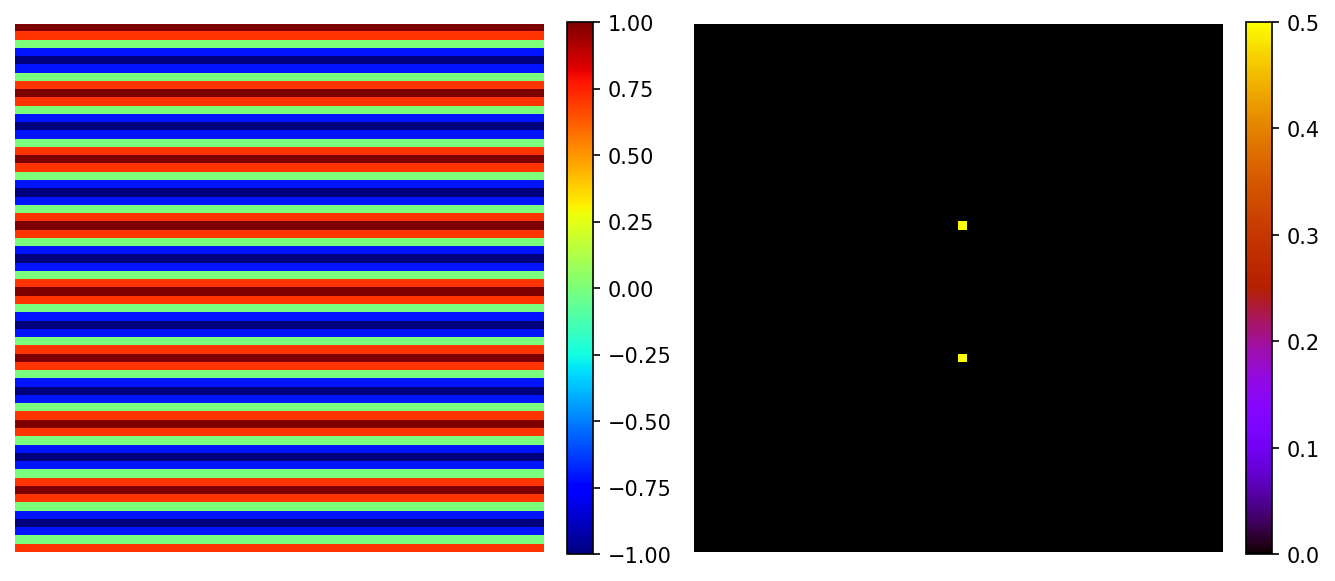

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(f3, cmap='jet')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(np.real(F3)/N**2, cmap='gnuplot')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_3.pdf', dpi=300)

plt.show()

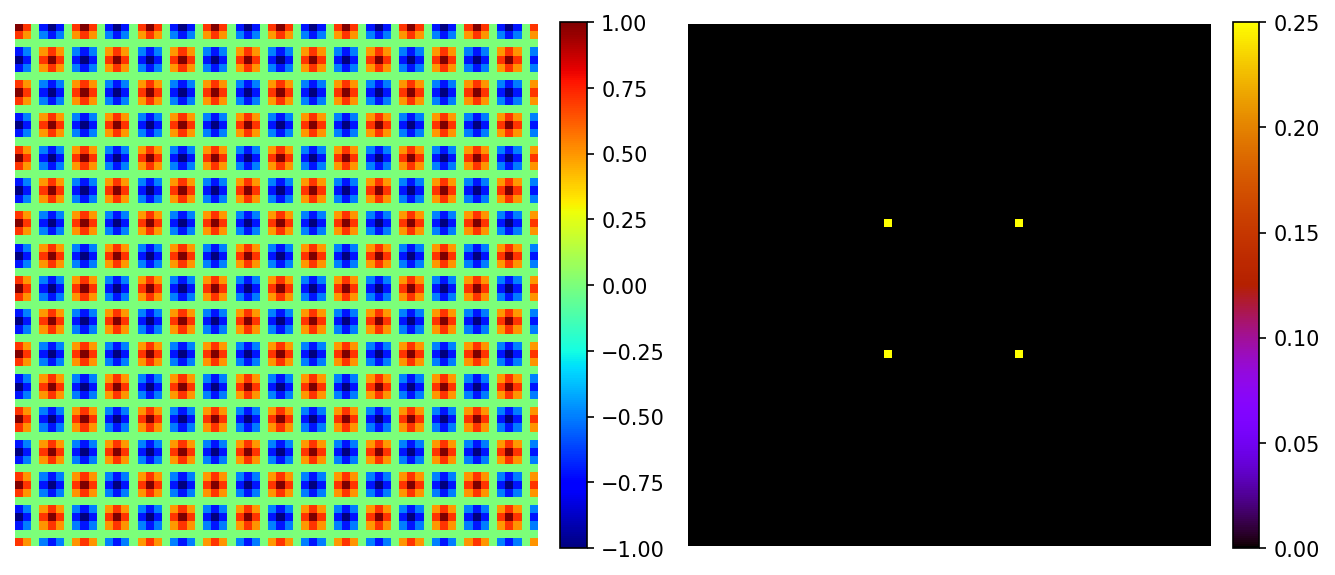

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(f4, cmap='jet')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(np.real(F4)/N**2, cmap='gnuplot')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_4.pdf', dpi=300)

plt.show()

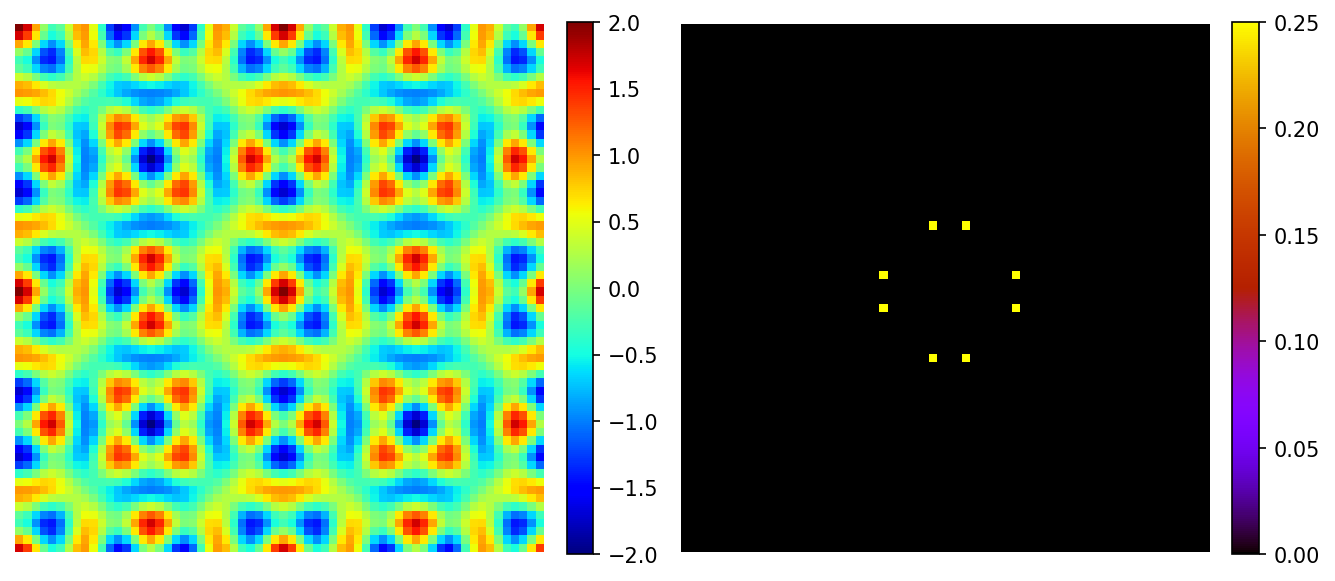

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(f5, cmap='jet')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(np.real(F5)/N**2, cmap='gnuplot')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_5.pdf', dpi=300)

plt.show()

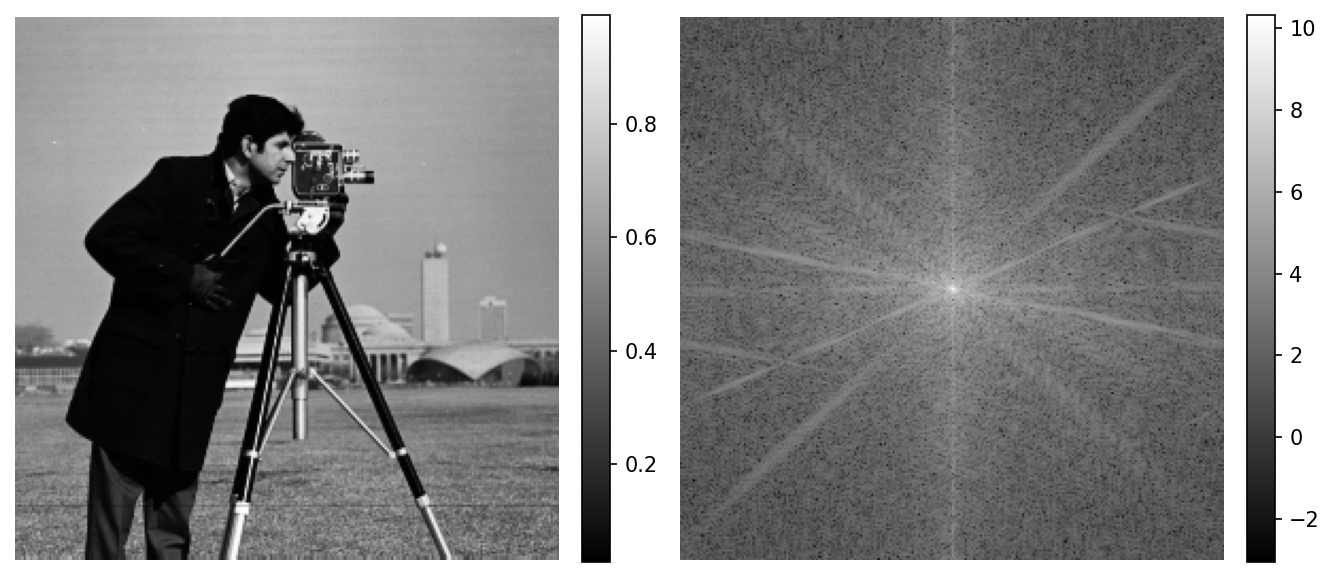

In [14]:
from matplotlib.image import imread
im_read = imread('figs/cameraman.png', 0)
F6 = np.fft.fft2(im_read);    F6 = sfft.fftshift(F6)

fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(np.real(im_read), cmap='gray')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(np.log(np.abs(F6)), cmap='gray')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_6.pdf', dpi=300)

plt.show()